In [162]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN
from typing import Callable
import networkx as nx
from sklearn.neighbors import NearestNeighbors


In [160]:
def lens(X):
    return X.iloc[:, 0].to_numpy()


def make_interval_cover(lens_values, n_intervals=12, overlap=0.3):
    min_val = lens_values.min()
    max_val = lens_values.max()

    padding = 0.1 * (max_val - min_val)
    min_val -= padding
    max_val += padding

    step = (max_val - min_val) / n_intervals
    overlap_amount = step * overlap

    cover_set = []

    for i in range(n_intervals):
        a = min_val + i * step - (overlap_amount if i > 0 else 0)
        b = min_val + (i + 1) * step + (overlap_amount if i < n_intervals - 1 else 0)

        cover_set.append((a, b))
    return cover_set

def plot_mapper_graph(vertex_set, edge_set, title="Mapper Graph"):
    G = nx.Graph()

    for i in range(len(vertex_set)):
        G.add_node(i)

    vertex_lookup = {frozenset(v): i for i, v in enumerate(vertex_set)}

    for v1, v2 in edge_set:
        i = vertex_lookup[frozenset(v1)]
        j = vertex_lookup[frozenset(v2)]
        G.add_edge(i, j)

    node_sizes = [max(100, len(v) * 1) for v in vertex_set]

    if len(G.nodes) == 0:
        print("Empty Mapper graph.")
        return

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)

    nx.draw(G,
            pos,
            with_labels=True,
            node_size=node_sizes,
            font_size=10)

    plt.title(title)
    plt.show()


def mapper(data: pd.DataFrame, lens: Callable, cover_set: list, clustering_alg: DBSCAN):
    vertex_set = []
    edge_set = []

    lens_values = lens(data)

    for i, Ui in enumerate(cover_set):
        ax, bx = Ui
        Xi = data[(lens_values >= ax) & (lens_values <= bx)]

        labels = clustering_alg.fit(Xi).labels_

        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)

        for j, cluster_label in enumerate(sorted(unique_labels)):

            members = Xi.index[labels == cluster_label]
            vertex = set(members)
            vertex_set.append(vertex)


    for i, vertex1 in enumerate(vertex_set):
        for j, vertex2 in enumerate(vertex_set):
            if i < j:
              if vertex1.intersection(vertex2):
                  edge_set.append((vertex1, vertex2))

    return vertex_set, edge_set


In [155]:
df = pd.read_csv('/content/noisy_annuli_bridge.csv')

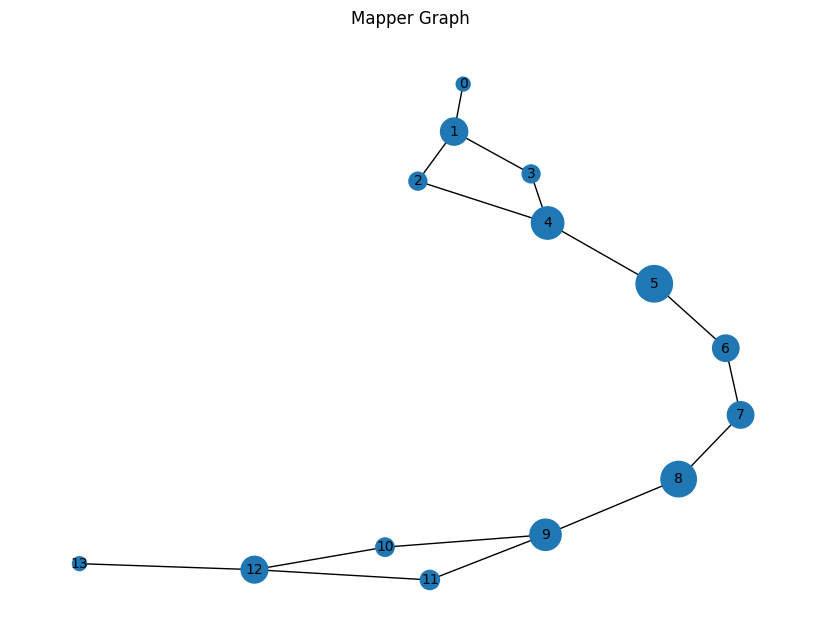

In [161]:
clustering_alg = DBSCAN(eps=0.6, min_samples=5)
data = df[['x', 'y']]



cover_set = make_interval_cover(lens(data), n_intervals=12, overlap=0.3)
vertex_set, edge_set = mapper(data, lens, cover_set, clustering_alg)
plot_mapper_graph(vertex_set, edge_set)

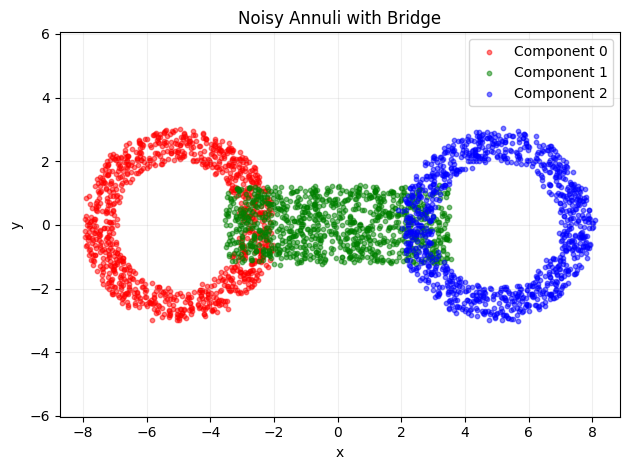

In [157]:
colors = ['red', 'green', 'blue']
for label, color in enumerate(colors):
    mask = df['label'] == label
    plt.scatter(df.loc[mask, 'x'], df.loc[mask, 'y'],
               color=color, alpha=0.5, s=10, label=f'Component {label}')

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Noisy Annuli with Bridge')
plt.legend()
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def dbscan_elbow(X, min_samples=5):
    """
    Plot k-distance graph for DBSCAN epsilon selection.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
    min_samples : int
        DBSCAN min_samples (k in k-distance plot)
    """
    neigh = NearestNeighbors(n_neighbors=min_samples)
    neigh.fit(X)

    distances, _ = neigh.kneighbors(X)
    k_distances = distances[:, -1]  # distance to k-th nearest neighbor
    k_distances = np.sort(k_distances)

    plt.figure(figsize=(6, 4))
    plt.plot(k_distances)
    plt.xlabel("Points sorted by distance")
    plt.ylabel(f"{min_samples}-NN distance")
    plt.title("DBSCAN ε Elbow (k-distance plot)")
    plt.grid(True)
    plt.show()

    return k_distances
